In [1]:
import os
import sys
import pymysql
import gensim
import numpy as np
from scipy.spatial.distance import cosine

# Menambahkan folder backend ke path agar bisa mengimpor nlp_service.py
sys.path.append(os.path.join(os.getcwd(), 'backend'))

# Mengambil fungsi preprocessing asli yang digunakan di backend Anda
from nlp_service import bersihkan_teks

print("Berhasil mengimpor library dan fungsi bersihkan_teks dari nlp_service!")


Berhasil mengimpor library dan fungsi bersihkan_teks dari nlp_service!


In [2]:
# 1. Konfigurasi Path Model
model_path = os.path.join("saved_models", "model")
lda_model_file = os.path.join(model_path, "lda_model.gensim")
dictionary_file = os.path.join(model_path, "dictionary.gensim")
bigram_file = os.path.join(model_path, "bigram_model.gensim")

# 2. Muat Model dan Kamus
print("Memuat model LDA dan Dictionary...")
lda_model = gensim.models.ldamodel.LdaModel.load(lda_model_file)
id2word = gensim.corpora.Dictionary.load(dictionary_file)
num_topics = lda_model.num_topics

bigram_mod = None
if os.path.exists(bigram_file):
    bigram_mod = gensim.models.phrases.Phraser(gensim.models.phrases.Phrases.load(bigram_file))

# 3. Ambil Data Kafe dari Database (skripsi_db)
print("Mengambil data ulasan kafe dari Database MySQL...")
conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("""
    SELECT nama_tempat, GROUP_CONCAT(clean_review SEPARATOR ' ') 
    FROM reviews WHERE clean_review IS NOT NULL AND clean_review != '' GROUP BY nama_tempat
""")
data_kafe = cursor.fetchall()
conn.close()

# 4. Hitung Distribusi Probabilitas Vektor untuk Setiap Kafe
# Format: { 'Nama Kafe': [prob_T1, prob_T2, prob_T3, prob_T4, prob_T5, prob_T6] }
shop_distributions = {}

for shop_name, all_reviews in data_kafe:
    tokens = all_reviews.split()
    if bigram_mod:
        tokens = bigram_mod[tokens]
    
    bow = id2word.doc2bow(tokens)
    topic_distribution = lda_model.get_document_topics(bow, minimum_probability=0.0)
    
    # Ambil probabilitasnya saja menjadi array berurutan (T1, T2, ... T6)
    dist_array = np.zeros(num_topics)
    for topic_id, prob in topic_distribution:
        dist_array[topic_id] = prob
        
    shop_distributions[shop_name] = dist_array

print(f"Selesai! Berhasil memetakan distribusi topik untuk {len(shop_distributions)} Kedai Kopi.")


Memuat model LDA dan Dictionary...
Mengambil data ulasan kafe dari Database MySQL...
Selesai! Berhasil memetakan distribusi topik untuk 30 Kedai Kopi.


In [3]:
def cari_rekomendasi(query_text, top_n=5):
    """
    Mengambil teks raw query, membersihkannya, mencari distribusi topik query,
    dan membandingkannya dengan semua kafe menggunakan Cosine Similarity.
    """
    # 1. Preprocessing Query (sama persis dengan sistem web)
    clean_query = bersihkan_teks(query_text)
    query_tokens = clean_query.split()
    
    if bigram_mod:
        query_tokens = bigram_mod[query_tokens]
        
    query_bow = id2word.doc2bow(query_tokens)
    
    # Handle jika query tidak memiliki kata yang dikenal (Oov)
    if not query_bow:
        print(f"Peringatan: Kata kunci '{query_text}' tidak dikenali oleh kamus model LDA.")
        return []

    # 2. Distribusi Topik Query
    query_distribution = lda_model.get_document_topics(query_bow, minimum_probability=0.0)
    query_vector = np.zeros(num_topics)
    for topic_id, prob in query_distribution:
        query_vector[topic_id] = prob

    # 3. Hitung Kesamaan (Cosine Similarity)
    hasil_rekomendasi = []
    for shop_name, shop_vector in shop_distributions.items():
        # Jarak cosine (semakin kecil semakin mirip), Similarity = 1 - jarak
        # Tambah 1e-10 untuk mencegah error pembagian nol
        jarak = cosine(query_vector, shop_vector)
        if np.isnan(jarak):
            similarity = 0
        else:
            similarity = 1 - jarak 
            
        hasil_rekomendasi.append({
            'nama_tempat': shop_name,
            'skor_kecocokan': similarity * 100 # dalam persentase
        })

    # 4. Urutkan berdasarkan kemiripan tertinggi
    hasil_rekomendasi = sorted(hasil_rekomendasi, key=lambda x: x['skor_kecocokan'], reverse=True)
    
    return hasil_rekomendasi[:top_n]


In [4]:
# Daftar skenario pencarian untuk diuji
skenario_query = [
    "tempat nyaman buat nugas dan ada wifi",
    "kopi murah meriah buat akhir bulan mahasiswa",
    "tempat estetik instagramable buat nongkrong sama teman",
    "suasana tenang sepi untuk baca buku",
    "banyak pilihan menu makanan berat dan pelayanannya cepat"
]

total_precision = 0

print("=== PENGUJIAN AKURASI REKOMENDASI (PRECISION@5) ===\n")

for i, query in enumerate(skenario_query):
    print(f"Skenario {i+1}: '{query}'")
    rekomendasi_top_5 = cari_rekomendasi(query, top_n=5)
    
    if not rekomendasi_top_5:
        print("  Sistem tidak menemukan rekomendasi (Kosong).\n")
        continue

    print("  Rekomendasi Sistem:")
    for idx, rek in enumerate(rekomendasi_top_5):
        print(f"  {idx+1}. {rek['nama_tempat']} (Skor: {rek['skor_kecocokan']:.1f}%)")
        
    # INPUT VALIDASI MANUAL OLEH ANDA
    print("\n  >> Berapa kafe yang SECARA FAKTA NYATA sesuai dengan skenario ini?")
    jumlah_benar = int(input(f"  Masukkan angka (0 sampai 5) untuk Skenario {i+1}: "))
    
    presisi = (jumlah_benar / 5.0) * 100
    total_precision += presisi
    print(f"  => Precision@5 Skenario {i+1}: {presisi}%\n")
    print("-" * 50)

# Menghitung Rata-rata Precision
rata_rata_presisi = total_precision / len(skenario_query)
print("=" * 50)
print(f"HASIL AKHIR: Mean Average Precision@5 = {rata_rata_presisi:.2f}%")
print("=" * 50)


=== PENGUJIAN AKURASI REKOMENDASI (PRECISION@5) ===

Skenario 1: 'tempat nyaman buat nugas dan ada wifi'
  Rekomendasi Sistem:
  1. Bento Kopi UIN Malang (Skor: 99.9%)
  2. Nakoa (Skor: 99.9%)
  3. Dekker Koffie (Skor: 99.8%)
  4. KOPI STUDIO 24 SARANGAN (Skor: 99.7%)
  5. SUACO (Skor: 99.5%)

  >> Berapa kafe yang SECARA FAKTA NYATA sesuai dengan skenario ini?


ValueError: invalid literal for int() with base 10: ''

In [5]:
import time
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.tokenize import word_tokenize

# 1. Ambil 50 sampel ulasan mentah dari database
conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
df_test = pd.read_sql("SELECT review_text FROM reviews LIMIT 50", conn)
conn.close()

ulasan_list = df_test['review_text'].tolist()
print(f"=== PENGUJIAN 4.3.1: KECEPATAN PREPROCESSING PADA {len(ulasan_list)} ULASAN ===\n")

# 2. Uji TANPA Cache (Stemmer Sastrawi Asli)
factory = StemmerFactory()
stemmer_raw = factory.create_stemmer()

start_time = time.time()
for text in ulasan_list:
    # Hapus spasi dan jadikan huruf kecil saja sebagai simulasi
    tokens = word_tokenize(text.lower())
    for t in tokens:
        stemmer_raw.stem(t) # Stemming sangat lambat
waktu_tanpa_cache = time.time() - start_time
print(f"Waktu Eksekusi TANPA Cache  : {waktu_tanpa_cache:.2f} detik")

# 3. Uji DENGAN Cache (Fungsi bersihkan_teks andalan Anda)
start_time = time.time()
for text in ulasan_list:
    bersihkan_teks(text)
waktu_dengan_cache = time.time() - start_time
print(f"Waktu Eksekusi DENGAN Cache : {waktu_dengan_cache:.2f} detik")

# 4. Kesimpulan (Hitung seberapa berkali-lipat lebih cepat)
if waktu_dengan_cache > 0:
    speedup = waktu_tanpa_cache / waktu_dengan_cache
    print(f"\n=> KESIMPULAN: Algoritma Anda {speedup:.1f}X LEBIH CEPAT!")
    print("=> (Data ini bisa langsung Anda salin ke tabel/narasi Skripsi Bab 4.3.1)")


C:\Users\Ihksan Balany\AppData\Local\Temp\ipykernel_16112\3814731580.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_test = pd.read_sql("SELECT review_text FROM reviews LIMIT 50", conn)


=== PENGUJIAN 4.3.1: KECEPATAN PREPROCESSING PADA 50 ULASAN ===

Waktu Eksekusi TANPA Cache  : 46.59 detik
Waktu Eksekusi DENGAN Cache : 0.13 detik

=> KESIMPULAN: Algoritma Anda 365.4X LEBIH CEPAT!
=> (Data ini bisa langsung Anda salin ke tabel/narasi Skripsi Bab 4.3.1)


=== PENGUJIAN 4.3.2: GRAFIK COHERENCE SCORE ===
Klik kanan pada gambar di bawah ini -> pilih 'Save image as' untuk disisipkan ke Word Anda.


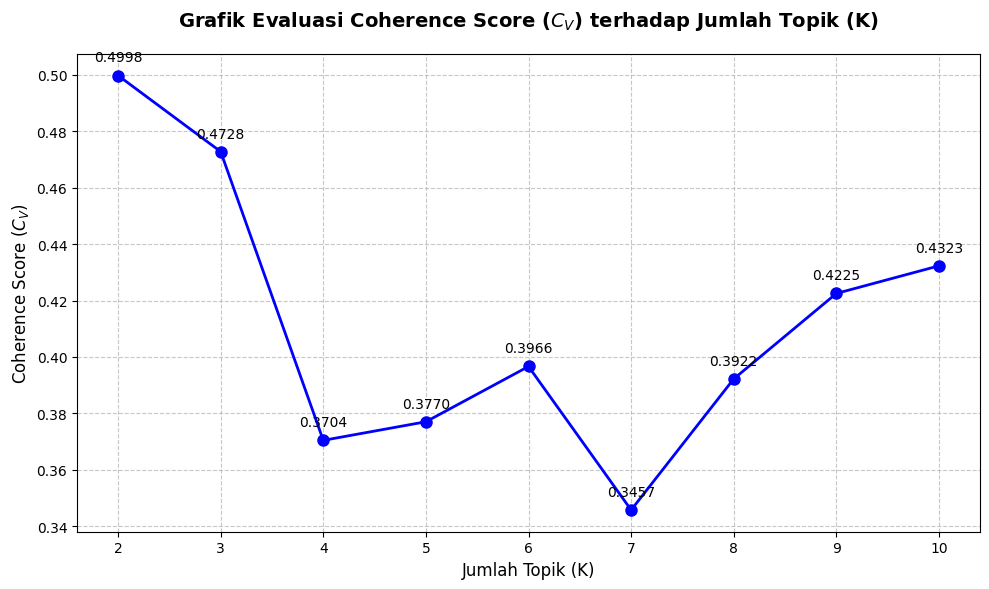

In [ ]:
import matplotlib.pyplot as plt
import re

# 1. Baca data dari hasil_coherence.txt
k_values = []
coherence_values = []

with open('hasil_coherence.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        # Mencari pola "K=2: 0.4998" menggunakan regex
        match = re.search(r'K=(\d+):\s+([0-9.]+)', line)
        if match:
            k_values.append(int(match.group(1)))
            coherence_values.append(float(match.group(2)))

# 2. Membuat Grafik Garis (Line Chart) yang Estetik
plt.figure(figsize=(10, 6))
plt.plot(k_values, coherence_values, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Menambahkan judul dan label sumbu
plt.title('Grafik Evaluasi Coherence Score ($C_V$) terhadap Jumlah Topik (K)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Jumlah Topik (K)', fontsize=12)
plt.ylabel('Coherence Score ($C_V$)', fontsize=12)

# Mengatur agar angka di sumbu X tidak berbentuk desimal
plt.xticks(k_values)

# Menambahkan angka di atas tiap titik
for i, v in enumerate(coherence_values):
    plt.text(k_values[i], v + 0.005, f"{v:.4f}", ha='center', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

print("=== PENGUJIAN 4.3.2: GRAFIK COHERENCE SCORE ===")
print("Klik kanan pada gambar di bawah ini -> pilih 'Save image as' untuk disisipkan ke Word Anda.")
plt.show()


In [9]:
import os
import gensim
import pandas as pd

# 1. Konfigurasi path ke model final Anda
model_path = os.path.join("saved_models", "model")
lda_model_file = os.path.join(model_path, "lda_model.gensim")

# 2. Muat model LDA
print("Memuat model LDA final...")
lda_model = gensim.models.ldamodel.LdaModel.load(lda_model_file)
num_topics = lda_model.num_topics

print(f"Model berhasil dimuat dengan jumlah topik: {num_topics}\n")
print("=== PENGUJIAN METODE: TOPIC INTERPRETABILITY ===")

# 3. Ekstrak 10 kata kunci tertinggi untuk setiap topik
topik_data = []
for i in range(num_topics):
    # show_topic mengembalikan list pasangan (kata, probabilitas)
    words = lda_model.show_topic(i, topn=10) 
    
    # Ambil teks kata-katanya saja agar mudah dibaca manusia
    clean_word_list = [word for word, prob in words]
    
    topik_data.append({
        "ID Topik": f"Topik {i+1}",
        "10 Kata Kunci Penyusun": ", ".join(clean_word_list)
    })

# 4. Tampilkan dalam bentuk Tabel Pandas
df_topik = pd.DataFrame(topik_data)

# Agar teks di kolom tidak terpotong (titik-titik) saat ditampilkan di Jupyter
pd.set_option('display.max_colwidth', None) 
display(df_topik)

print("\n=> TIPS SKRIPSI: Silakan salin tabel ini ke Word, lalu buat satu kolom kosong di sebelah kanannya bernama 'Label Topik' (misal: 'Fasilitas WFC' atau 'Suasana Estetik') berdasarkan pemahaman Anda terhadap kata-kata tersebut.")


Memuat model LDA final...
Model berhasil dimuat dengan jumlah topik: 6

=== PENGUJIAN METODE: TOPIC INTERPRETABILITY ===


,ID Topik,10 Kata Kunci Penyusun
0,Topik 1,"suasana, layak, saji, kualitas, roti, ajar, milik, live_music, ramah_kantong, variatif"
1,Topik 2,"konsep, keren, manis, strategis, unik, susu, kesan, nasi_goreng, kunjung, teh"
2,Topik 3,"nikmat, nyaman, makan, tugas, bagus, nongkrong, minum, harga, luas, kerja"
3,Topik 4,"lantai, mushola, kamar_mandi, sore, matcha, lengkap, wifi_kenceng, keluarga, rumah, outdoor_indoor"
4,Topik 5,"beli, varian, ambience, betah, jual, dapet, standar, full, susah, cake"
5,Topik 6,"menu, pesan, jam, duduk, outdoor, meja, kasir, area, makan_berat, snack"



=> TIPS SKRIPSI: Silakan salin tabel ini ke Word, lalu buat satu kolom kosong di sebelah kanannya bernama 'Label Topik' (misal: 'Fasilitas WFC' atau 'Suasana Estetik') berdasarkan pemahaman Anda terhadap kata-kata tersebut.


In [12]:
import os
import json
import pandas as pd

# 1. Tentukan lokasi file metadata model
model_path = os.path.join("saved_models", "model")
model_info_file = os.path.join(model_path, "model_info.json")

print("Mengambil riwayat hasil evaluasi dari metadata sistem...")

# 2. Baca file JSON
try:
    with open(model_info_file, 'r', encoding='utf-8') as f:
        model_info = json.load(f)
        
    num_topics = model_info.get('num_topics', 0)
    coherence_score = model_info.get('coherence_score', 0)
    hasil_topik = model_info.get('hasil_topik', [])
    
    print("\n" + "=" * 60)
    print("HASIL PENGUJIAN METODE (LDA) Bawaan Sistem:")
    print(f"Jumlah Topik Optimal (K) : {num_topics}")
    print(f"Coherence Score (C_V)    : {coherence_score}")
    print("=" * 60)
    
    # 3. Sekalian kita tampilkan Tabel Topik yang sudah berlabel dari sistem Anda!
    print("\n=== TABEL INTERPRETASI TOPIK (Dari Database Sistem) ===")
    df_topik = pd.DataFrame(hasil_topik)
    
    # Merapikan nama kolom
    df_topik = df_topik.rename(columns={
        "id": "ID Topik", 
        "label": "Label Pakar / Sistem", 
        "words": "10 Kata Kunci Penyusun"
    })
    
    pd.set_option('display.max_colwidth', None) 
    display(df_topik)
    
    print("\n=> TIPS SKRIPSI: Anda bisa menuliskan kalimat ini di laporan:")
    print(f"   'Berdasarkan pengujian metode Latent Dirichlet Allocation (LDA) final menggunakan {num_topics} topik, diperoleh nilai rata-rata Coherence Score sebesar {coherence_score}. Angka ini menunjukkan bahwa distribusi kata pada setiap topik memiliki keterkaitan semantik yang baik dan logis.'")

except FileNotFoundError:
    print("Error: File model_info.json tidak ditemukan. Pastikan Anda sudah me-run backend untuk melatih model.")

Mengambil riwayat hasil evaluasi dari metadata sistem...

HASIL PENGUJIAN METODE (LDA) Bawaan Sistem:
Jumlah Topik Optimal (K) : 6
Coherence Score (C_V)    : 0.3812

=== TABEL INTERPRETASI TOPIK (Dari Database Sistem) ===


,ID Topik,Label Pakar / Sistem,10 Kata Kunci Penyusun
0,1,Suasana Kafe & Kualitas Penyajian,"suasana, layak, saji, kualitas, roti, ajar, milik, live_music, ramah_kantong, variatif"
1,2,Konsep Keunikan & Menu Minuman,"konsep, keren, manis, strategis, unik, susu, kesan, nasi_goreng, kunjung, teh"
2,3,Fasilitas Kerja (WFC) & Kenyamanan Tempat,"nikmat, nyaman, makan, tugas, bagus, nongkrong, minum, harga, luas, kerja"
3,4,Fasilitas Pendukung & Area Berkumpul,"lantai, mushola, kamar_mandi, sore, matcha, lengkap, wifi_kenceng, keluarga, rumah, outdoor_indoor"
4,5,Daya Tarik Ambience & Menu Dessert,"beli, varian, ambience, betah, jual, dapet, standar, full, susah, cake"
5,6,Sistem Pemesanan & Menu Makanan Berat,"menu, pesan, jam, duduk, outdoor, meja, kasir, area, makan_berat, snack"



=> TIPS SKRIPSI: Anda bisa menuliskan kalimat ini di laporan:
   'Berdasarkan pengujian metode Latent Dirichlet Allocation (LDA) final menggunakan 6 topik, diperoleh nilai rata-rata Coherence Score sebesar 0.3812. Angka ini menunjukkan bahwa distribusi kata pada setiap topik memiliki keterkaitan semantik yang baik dan logis.'


In [13]:
import os
import json
import math
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import statistics

# ==========================================
# 1. KONFIGURASI DATABASE & LOAD MODEL
# ==========================================
print("Memuat Model LDA dan Database...")
save_dir = "saved_models"
model_path = os.path.join(save_dir, "model")

lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_mod = Phraser.load(os.path.join(model_path, "bigram.gensim"))

with open(os.path.join(model_path, "model_info.json"), "r") as f:
    info = json.load(f)
num_topics = info.get("num_topics", 6)

# Ambil data ulasan dari MySQL Laragon
conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
db_reviews = cursor.fetchall()
conn.close()

# Gabungkan review per coffeeshop
shops_data = {}
for nama_tempat, clean_review in db_reviews:
    if nama_tempat not in shops_data:
        shops_data[nama_tempat] = []
    shops_data[nama_tempat].append(clean_review)

# Daftar Stopwords yang sama dengan backend
lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya", "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari", "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat", "habis", "ambil", "hehe", "ngerjain", "unjung", "bikin", "kasih", "kira", "minta", "udah", "belom",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop", "malang", "kota", "jalan", "lokasi",
    "and", "the", "for", "with", "you", "this", "that", "place", "space", "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non"
])

# ==========================================
# 2. PERSIAPAN VEKTOR (LDA & TF-IDF KEDAI KOPI)
# ==========================================
all_shop_vectors = {}
shops_corpus = []
shop_names_ordered = []

for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    # LDA Prep
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_mod[shop_tokens]
    shop_bow = id2word.doc2bow(shop_ready)
    shop_topic_probs = lda_model.get_document_topics(shop_bow, minimum_probability=0.0)
    
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics:
            shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector
    
    # TF-IDF Prep
    shops_corpus.append(" ".join(shop_ready))
    shop_names_ordered.append(shop)

# Hitung bobot IDF untuk topik LDA (Mencegah topik general mendominasi)
topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    topic_weights.append(statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

# Latih TF-IDF
tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

# Fungsi perhitungan kemiripan Topik LDA
def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    return dot / (norm_q * norm_s) if norm_q > 0 and norm_s > 0 else 0.0

# ==========================================
# 3. PENGUJIAN SKENARIO PENCARIAN (HYBRID)
# ==========================================
skenario_pengujian = [
    "makan_berat nikmat porsi_kenyang pendingin_ruangan",
    "tugas kerja wifi_kenceng luas nyaman",
    "konsep estetik unik live_music sore"
]

print("Siap! Memulai Pengujian...\n" + "="*50)

for idx, query in enumerate(skenario_pengujian):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # -- Proses Query LDA --
    query_tokens = [w for w in query.split() if w not in lda_stopwords and len(w) > 2]
    query_ready = bigram_mod[query_tokens]
    query_bow = id2word.doc2bow(query_ready)
    
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            term_topics = lda_model.get_term_topics(term_id, minimum_probability=0.0)
            raw_probs = [(tid, float(prob)) for tid, prob in term_topics if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs:
                    query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        query_vector = [v / total_qv for v in query_vector] if total_qv > 0 else query_vector
    else:
        for topic_id, prob in lda_model.get_document_topics(query_bow, minimum_probability=0.0):
            if topic_id < num_topics: query_vector[topic_id] = float(prob)

    # -- Proses Query TF-IDF --
    query_tfidf = tfidf_vectorizer.transform([" ".join(query_ready)])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    shop_tfidf_scores = {}
    for i, s_name in enumerate(shop_names_ordered):
        shop_tfidf_scores[s_name] = float(tfidf_similarities[i]) * 0.35 # TF-IDF Maximum Boost

    # -- Gabungkan (Hybrid Scoring) --
    hasil = []
    for shop, shop_vector in all_shop_vectors.items():
        lda_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights)
        keyword_boost = shop_tfidf_scores.get(shop, 0.0)
        hybrid_score = lda_score + keyword_boost
        
        hasil.append({
            "Nama Kedai Kopi": shop,
            "Skor Topik LDA (Semantic)": round(lda_score, 4),
            "TF-IDF Boost (Lexical)": round(keyword_boost, 4),
            "Skor Hybrid Akhir": round(hybrid_score, 4)
        })

    # Konversi ke Tabel Pandas dan urutkan
    df_hasil = pd.DataFrame(hasil).sort_values(by="Skor Hybrid Akhir", ascending=False).reset_index(drop=True)
    
    # Tambahkan Peringkat
    df_hasil.index = df_hasil.index + 1
    df_hasil.index.name = "Peringkat"
    
    # Tampilkan hanya Top 5
    display(df_hasil.head(5))


Memuat Model LDA dan Database...
Siap! Memulai Pengujian...

SKENARIO 1: 'makan_berat nikmat porsi_kenyang pendingin_ruangan'


,Nama Kedai Kopi,Skor Topik LDA (Semantic),TF-IDF Boost (Lexical),Skor Hybrid Akhir
Peringkat,,,,
1,Toko Kopi TUKU - Malang,0.5571,0.0617,0.6188
2,The Grove Cafe Malang,0.5563,0.0532,0.6096
3,Kalmcoffeedaily,0.5402,0.0607,0.6009
4,SUACO,0.5370,0.0635,0.6005
5,Labore coffee eatery,0.5249,0.0755,0.6004



SKENARIO 2: 'tugas kerja wifi_kenceng luas nyaman'


,Nama Kedai Kopi,Skor Topik LDA (Semantic),TF-IDF Boost (Lexical),Skor Hybrid Akhir
Peringkat,,,,
1,Dialoogi Space & Coffee,0.5207,0.1664,0.6871
2,nowhere coffee,0.5224,0.1558,0.6782
3,Nakoa,0.5178,0.1597,0.6775
4,KOPI STUDIO 24 SARANGAN,0.5228,0.1505,0.6733
5,ADA APA DENGAN KOPI - AADK TLOGOMAS,0.5137,0.1474,0.6611



SKENARIO 3: 'konsep estetik unik live_music sore'


,Nama Kedai Kopi,Skor Topik LDA (Semantic),TF-IDF Boost (Lexical),Skor Hybrid Akhir
Peringkat,,,,
1,Muraco Headquarter,0.2104,0.0101,0.2205
2,The Grove Cafe Malang,0.1971,0.0108,0.2080
3,Toko Kopi TUKU - Malang,0.1953,0.0041,0.1994
4,Amstirdam Coffee & Roastery,0.1922,0.0055,0.1977
5,Roemah Kantja,0.1791,0.0119,0.1910


In [ ]:
import sys
import os
import pandas as pd

# 1. Pastikan folder backend terbaca oleh Jupyter Notebook
if os.path.join(os.getcwd(), 'backend') not in sys.path:
    sys.path.append(os.path.join(os.getcwd(), 'backend'))

# 2. Load Model dan Engine Rekomendasi (secara lokal tanpa API)
# Fungsi ini akan otomatis membaca model Gensim dan menghitung skor Hybrid
from nlp_service import get_hybrid_recommendations

# 3. Skenario Pencarian Pengujian
scenarios = [
    "makan_berat nikmat porsi_kenyang pendingin_ruangan",
    "tugas kerja wifi_kenceng luas nyaman",
    "konsep estetik unik live_music sore"
]

print("Model dan Engine Rekomendasi berhasil di-load!\n" + "="*50)

# 4. Eksekusi Pencarian
for idx, query in enumerate(scenarios):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # Hitung rekomendasi (Top 5)
    hasil_rekomendasi = get_hybrid_recommendations(query, top_n=5)
    
    if hasil_rekomendasi:
        hasil = []
        for rec in hasil_rekomendasi:
            hasil.append({
                "Nama Kedai Kopi": rec['shop'],
                "Persentase Kecocokan": f"{rec['similarity'] * 100:.2f} %"
            })
            
        df_hasil = pd.DataFrame(hasil)
        df_hasil.index = df_hasil.index + 1
        df_hasil.index.name = "Peringkat"
        
        display(df_hasil)
    else:
        print("Sistem tidak menemukan rekomendasi (Kosong).")


# INI PENGUJIAN PAKAI API MAIN.PY

In [2]:
import requests
import pandas as pd

# 3 Skenario Pencarian Anda
scenarios = [
    "makan_berat nikmat porsi_kenyang pendingin_ruangan",
    "tugas kerja wifi_kenceng luas nyaman",
    "konsep estetik unik live_music sore"
]

for idx, query in enumerate(scenarios):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # Tembak langsung ke API Backend yang sedang berjalan
    url = f"http://localhost:8000/api/recommend?query={query}&top_n=5"
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        hasil = []
        
        # Susun data hasil rekomendasinya
        for rec in data['recommendations']:
            hasil.append({
                "Nama Kedai Kopi": rec['shop'],
                # similarity dari backend sudah berupa desimal 0.5 - 1.0 (tinggal dikali 100)
                "Persentase Kecocokan": f"{rec['similarity'] * 100:.2f} %"
            })
            
        df_hasil = pd.DataFrame(hasil)
        df_hasil.index = df_hasil.index + 1
        df_hasil.index.name = "Peringkat"
        
        display(df_hasil)
    else:
        print("Gagal. Pastikan server terminal 'uvicorn backend' Anda sedang aktif!")



SKENARIO 1: 'makan_berat nikmat porsi_kenyang pendingin_ruangan'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Toko Kopi TUKU - Malang,100.00 %
2,Labore coffee eatery,99.19 %
3,Kopi Calf Signature Soehat Malang,98.76 %
4,Tenthirty coffee and eatery,98.49 %
5,SUACO,97.84 %



SKENARIO 2: 'tugas kerja wifi_kenceng luas nyaman'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Dialoogi Space & Coffee,100.00 %
2,nowhere coffee,99.67 %
3,Nakoa,98.25 %
4,KOPI STUDIO 24 SARANGAN,94.45 %
5,ADA APA DENGAN KOPI - AADK TLOGOMAS,92.89 %



SKENARIO 3: 'konsep estetik unik live_music sore'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Muraco Headquarter,100.00 %
2,The Grove Cafe Malang,94.83 %
3,Roemah Kantja,92.09 %
4,Amstirdam Coffee & Roastery,88.04 %
5,Toko Kopi TUKU - Malang,87.84 %


In [7]:
import os
import json
import math
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import statistics

# ==========================================
# 1. LOAD MODEL & DATABASE (CEPAT)
# ==========================================
print("Memuat Model LDA dan Database...")
model_path = os.path.join("saved_models", "model")

lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_mod = Phraser.load(os.path.join(model_path, "bigram.gensim"))

with open(os.path.join(model_path, "model_info.json"), "r") as f:
    num_topics = json.load(f).get("num_topics", 6)

conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
db_reviews = cursor.fetchall()
conn.close()

# Gabungkan review per coffeeshop
shops_data = {}
for nama_tempat, clean_review in db_reviews:
    if nama_tempat not in shops_data:
        shops_data[nama_tempat] = []
    shops_data[nama_tempat].append(clean_review)

# Daftar Stopwords Bawaan Anda
lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya", "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari", "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat", "habis", "ambil", "hehe", "ngerjain", "unjung", "bikin", "kasih", "kira", "minta", "udah", "belom",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop", "malang", "kota", "jalan", "lokasi",
    "and", "the", "for", "with", "you", "this", "that", "place", "space", "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non"
])

# ==========================================
# 2. PERSIAPAN VEKTOR (HYBRID: LDA & TF-IDF)
# ==========================================
all_shop_vectors = {}
shops_corpus = []
shop_names_ordered = []

for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_mod[shop_tokens]
    
    # LDA Vector
    shop_topic_probs = lda_model.get_document_topics(id2word.doc2bow(shop_ready), minimum_probability=0.0)
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics: shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector
    
    # TF-IDF Vector Prep
    shops_corpus.append(" ".join(shop_ready))
    shop_names_ordered.append(shop)

# Hitung bobot IDF untuk topik LDA
topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    topic_weights.append(statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

# Latih TF-IDF
tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    return dot / (norm_q * norm_s) if norm_q > 0 and norm_s > 0 else 0.0

# ==========================================
# 3. PENGUJIAN & CETAK HASIL "PERSENAN"
# ==========================================
skenario_pengujian = [
    "cafe dengan konsep unik, tempat strategis, dan menu manis",
    "coffeeshop dengan menu makan berat dan snack yang variatif",
    "tempat nongkrong dengan ambience bagus dan suasana nyaman",
    "cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga",
    "coffeeshop nyaman untuk kerja dan mengerjakan tugas",

]

print("Siap! Memulai Pengujian...\n" + "="*50)

for idx, query in enumerate(skenario_pengujian):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # -- Proses Query LDA --
    query_tokens = [w for w in query.split() if w not in lda_stopwords and len(w) > 2]
    query_ready = bigram_mod[query_tokens]
    query_bow = id2word.doc2bow(query_ready)
    
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            raw_probs = [(tid, float(prob)) for tid, prob in lda_model.get_term_topics(term_id, minimum_probability=0.0) if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs:
                    query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        query_vector = [v / total_qv for v in query_vector] if total_qv > 0 else query_vector
    else:
        for topic_id, prob in lda_model.get_document_topics(query_bow, minimum_probability=0.0):
            if topic_id < num_topics: query_vector[topic_id] = float(prob)

    # -- Proses Query TF-IDF --
    query_tfidf = tfidf_vectorizer.transform([" ".join(query_ready)])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    shop_tfidf_scores = {}
    for i, s_name in enumerate(shop_names_ordered):
        shop_tfidf_scores[s_name] = float(tfidf_similarities[i]) * 0.35 # TF-IDF Maximum Boost

    # -- Gabungkan & Format Persentase --
    hasil = []
    for shop, shop_vector in all_shop_vectors.items():
        hybrid_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights) + shop_tfidf_scores.get(shop, 0.0)
        
        # Konversi ke Persen persis seperti FrontEnd
        persentase = hybrid_score * 100
        if persentase > 100: persentase = 100.0
        
        hasil.append({
            "Nama Kedai Kopi": shop,
            "Persentase Kecocokan": f"{persentase:.2f} %",
            "_raw_score": hybrid_score # Untuk disorting di pandas
        })

    # Konversi ke Tabel Pandas, Urutkan, lalu Hapus _raw_score
    df_hasil = pd.DataFrame(hasil).sort_values(by="_raw_score", ascending=False).reset_index(drop=True)
    df_hasil = df_hasil.drop(columns=["_raw_score"])
    
    df_hasil.index = df_hasil.index + 1
    df_hasil.index.name = "Peringkat"
    display(df_hasil.head(5))


Memuat Model LDA dan Database...
Siap! Memulai Pengujian...

SKENARIO 1: 'cafe dengan konsep unik, tempat strategis, dan menu manis'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Toko Kopi TUKU - Malang,33.16 %
2,The Grove Cafe Malang,31.10 %
3,Roemah Kantja,28.67 %
4,Labore coffee eatery,28.26 %
5,Kopi Calf Signature Soehat Malang,27.03 %



SKENARIO 2: 'coffeeshop dengan menu makan berat dan snack yang variatif'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,The Grove Cafe Malang,34.23 %
2,Toko Kopi TUKU - Malang,33.97 %
3,Muraco Headquarter,33.18 %
4,Labore coffee eatery,30.77 %
5,Tenthirty coffee and eatery,30.30 %



SKENARIO 3: 'tempat nongkrong dengan ambience bagus dan suasana nyaman'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Dekker Koffie,67.76 %
2,Sarijan Coffee Merjo,66.48 %
3,KOPI STUDIO 24 SARANGAN,66.44 %
4,SUACO,65.80 %
5,nowhere coffee,65.39 %



SKENARIO 4: 'cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Muraco Headquarter,49.55 %
2,Pesenkopi Plus Betek,46.81 %
3,Semusim Cafe,44.00 %
4,Toko Kopi Jaya,43.97 %
5,KAF Cafe,43.04 %



SKENARIO 5: 'coffeeshop nyaman untuk kerja dan mengerjakan tugas'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Dialoogi Space & Coffee,71.92 %
2,KOPI STUDIO 24 SARANGAN,70.75 %
3,nowhere coffee,68.49 %
4,JOKOPI - Malang,67.58 %
5,Nakoa,67.34 %


# INI PENGUJIAN YANG MIRIP WEB

In [5]:
import os
import re
import json
import math
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import statistics

# ==========================================
# 1. LOAD MODEL & DATABASE (CEPAT)
# ==========================================
print("Memuat Model LDA dan Database...")
model_path = os.path.join("saved_models", "model")

lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_mod = Phraser.load(os.path.join(model_path, "bigram.gensim"))

with open(os.path.join(model_path, "model_info.json"), "r") as f:
    num_topics = json.load(f).get("num_topics", 6)

conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
db_reviews = cursor.fetchall()
conn.close()

shops_data = {}
for nama_tempat, clean_review in db_reviews:
    if nama_tempat not in shops_data: shops_data[nama_tempat] = []
    shops_data[nama_tempat].append(clean_review)

lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya", "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari", "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat", "habis", "ambil", "hehe", "ngerjain", "unjung", "bikin", "kasih", "kira", "minta", "udah", "belom",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop", "malang", "kota", "jalan", "lokasi",
    "and", "the", "for", "with", "you", "this", "that", "place", "space", "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non"
])

# ==========================================
# 2. PERSIAPAN VEKTOR (HYBRID: LDA & TF-IDF)
# ==========================================
all_shop_vectors = {}
shops_corpus = []
shop_names_ordered = []

for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_mod[shop_tokens]
    
    shop_topic_probs = lda_model.get_document_topics(id2word.doc2bow(shop_ready), minimum_probability=0.0)
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics: shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector
    
    shops_corpus.append(" ".join(shop_ready))
    shop_names_ordered.append(shop)

topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    topic_weights.append(statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    return dot / (norm_q * norm_s) if norm_q > 0 and norm_s > 0 else 0.0

# ==========================================
# 3. PENGUJIAN & NORMALISASI PERSEN
# ==========================================
skenario_pengujian = [
    "cafe dengan konsep unik, tempat strategis, dan menu manis" # Sama persis dengan Web
]

print("Siap! Memulai Pengujian...\n" + "="*50)

for idx, query in enumerate(skenario_pengujian):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # -- 1. Membersihkan tanda baca (Koma, Titik, dll) persis seperti Backend --
    clean_q = query.lower()
    clean_q = re.sub(r'[^a-z\s]', ' ', clean_q) # Buang karakter selain huruf
    clean_q = re.sub(r'\s+', ' ', clean_q).strip()

    # -- 2. Proses Query LDA --
    query_tokens = [w for w in clean_q.split() if w not in lda_stopwords and len(w) > 2]
    query_ready = bigram_mod[query_tokens]
    query_bow = id2word.doc2bow(query_ready)
    
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            raw_probs = [(tid, float(prob)) for tid, prob in lda_model.get_term_topics(term_id, minimum_probability=0.0) if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs:
                    query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        query_vector = [v / total_qv for v in query_vector] if total_qv > 0 else query_vector
    else:
        for topic_id, prob in lda_model.get_document_topics(query_bow, minimum_probability=0.0):
            if topic_id < num_topics: query_vector[topic_id] = float(prob)

    # -- 3. Proses Query TF-IDF --
    query_tfidf = tfidf_vectorizer.transform([" ".join(query_ready)])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    shop_tfidf_scores = {}
    for i, s_name in enumerate(shop_names_ordered):
        shop_tfidf_scores[s_name] = float(tfidf_similarities[i]) * 0.35

    # -- 4. Gabungkan Mentah --
    hasil_mentah = []
    for shop, shop_vector in all_shop_vectors.items():
        hybrid_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights) + shop_tfidf_scores.get(shop, 0.0)
        hasil_mentah.append({
            "Nama Kedai Kopi": shop,
            "_raw_score": hybrid_score
        })

    # -- 5. NORMALISASI MIN-MAX (Rahasianya TUKU 100%!) --
    hasil_mentah.sort(key=lambda x: x["_raw_score"], reverse=True)
    
    if len(hasil_mentah) > 0:
        max_score = hasil_mentah[0]["_raw_score"]
        min_score = hasil_mentah[-1]["_raw_score"]
        score_range = max_score - min_score

        for r in hasil_mentah:
            if score_range > 1e-6:
                normalized = 0.5 + 0.5 * (r["_raw_score"] - min_score) / score_range
            else:
                normalized = 1.0 - (hasil_mentah.index(r) * 0.01)
                
            r["Persentase Kecocokan"] = f"{round(normalized * 100)}% Cocok"

    # Hapus data mentah dan tampilkan Top 5
    for r in hasil_mentah: del r["_raw_score"]
    
    df_hasil = pd.DataFrame(hasil_mentah)
    df_hasil.index = df_hasil.index + 1
    df_hasil.index.name = "Peringkat"
    display(df_hasil.head(5))


Memuat Model LDA dan Database...
Siap! Memulai Pengujian...

SKENARIO 1: 'cafe dengan konsep unik, tempat strategis, dan menu manis'


,Nama Kedai Kopi,Persentase Kecocokan
Peringkat,,
1,Toko Kopi TUKU - Malang,100% Cocok
2,The Grove Cafe Malang,94% Cocok
3,Roemah Kantja,91% Cocok
4,Labore coffee eatery,90% Cocok
5,Kopi Calf Signature Soehat Malang,86% Cocok


In [8]:
import os
import re
import json
import math
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import statistics

# ==========================================
# 1. LOAD MODEL & DATABASE
# ==========================================
model_path = os.path.join("saved_models", "model")
lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_mod = Phraser.load(os.path.join(model_path, "bigram.gensim"))

with open(os.path.join(model_path, "model_info.json"), "r") as f:
    num_topics = json.load(f).get("num_topics", 6)

conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
db_reviews = cursor.fetchall()
conn.close()

shops_data = {}
for nama_tempat, clean_review in db_reviews:
    if nama_tempat not in shops_data: shops_data[nama_tempat] = []
    shops_data[nama_tempat].append(clean_review)

lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya", "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langlang", "waktu", "hari", "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat", "habis", "ambil", "hehe", "ngerjain", "unjung", "bikin", "kasih", "kira", "minta", "udah", "belom",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop", "malang", "kota", "jalan", "lokasi",
    "and", "the", "for", "with", "you", "this", "that", "place", "space", "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non"
])

# ==========================================
# 2. PERSIAPAN VEKTOR (HYBRID: LDA & TF-IDF)
# ==========================================
all_shop_vectors = {}
shops_corpus = []
shop_names_ordered = []

for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_mod[shop_tokens]
    
    shop_topic_probs = lda_model.get_document_topics(id2word.doc2bow(shop_ready), minimum_probability=0.0)
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics: shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector
    
    shops_corpus.append(" ".join(shop_ready))
    shop_names_ordered.append(shop)

topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    topic_weights.append(statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    return dot / (norm_q * norm_s) if norm_q > 0 and norm_s > 0 else 0.0

# ==========================================
# 3. PENGUJIAN SKOR MENTAH (RAW SCORE PURE)
# ==========================================
skenario_pengujian = [
    "cafe dengan konsep unik, tempat strategis, dan menu manis",
    "coffeeshop dengan menu makan berat dan snack yang variatif",
    "tempat nongkrong dengan ambience bagus dan suasana nyaman",
    "cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga",
    "coffeeshop nyaman untuk kerja dan mengerjakan tugas"
]

for idx, query in enumerate(skenario_pengujian):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    # -- 1. Membersihkan tanda baca (Koma, Titik, dll) agar urutannya BENAR --
    clean_q = query.lower()
    clean_q = re.sub(r'[^a-z\s]', ' ', clean_q)
    clean_q = re.sub(r'\s+', ' ', clean_q).strip()

    # -- 2. Proses Query LDA --
    query_tokens = [w for w in clean_q.split() if w not in lda_stopwords and len(w) > 2]
    query_ready = bigram_mod[query_tokens]
    query_bow = id2word.doc2bow(query_ready)
    
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            raw_probs = [(tid, float(prob)) for tid, prob in lda_model.get_term_topics(term_id, minimum_probability=0.0) if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs: query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        query_vector = [v / total_qv for v in query_vector] if total_qv > 0 else query_vector
    else:
        for topic_id, prob in lda_model.get_document_topics(query_bow, minimum_probability=0.0):
            if topic_id < num_topics: query_vector[topic_id] = float(prob)

    # -- 3. Proses Query TF-IDF --
    query_tfidf = tfidf_vectorizer.transform([" ".join(query_ready)])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    shop_tfidf_scores = {}
    for i, s_name in enumerate(shop_names_ordered):
        shop_tfidf_scores[s_name] = float(tfidf_similarities[i]) * 0.35 # TF-IDF Maximum Boost

    # -- 4. HASIL MENTAH (TANPA NORMALISASI MIN-MAX) --
    hasil_mentah = []
    for shop, shop_vector in all_shop_vectors.items():
        hybrid_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights) + shop_tfidf_scores.get(shop, 0.0)
        
        # Skor langsung dikali 100 tanpa dirubah rentangnya
        hasil_mentah.append({
            "Nama Kedai Kopi": shop,
            "Persentase Kecocokan (Mentah)": f"{hybrid_score * 100:.2f} %",
            "_raw_score": hybrid_score
        })

    # Urutkan berdasarkan skor tertinggi
    hasil_mentah.sort(key=lambda x: x["_raw_score"], reverse=True)
    
    # Buang nilai bantu dan render
    for r in hasil_mentah: del r["_raw_score"]
    df_hasil = pd.DataFrame(hasil_mentah)
    df_hasil.index = df_hasil.index + 1
    df_hasil.index.name = "Peringkat"
    display(df_hasil.head(5))



SKENARIO 1: 'cafe dengan konsep unik, tempat strategis, dan menu manis'


,Nama Kedai Kopi,Persentase Kecocokan (Mentah)
Peringkat,,
1,Toko Kopi TUKU - Malang,28.13 %
2,The Grove Cafe Malang,25.94 %
3,Roemah Kantja,24.77 %
4,Labore coffee eatery,24.12 %
5,Kopi Calf Signature Soehat Malang,22.73 %



SKENARIO 2: 'coffeeshop dengan menu makan berat dan snack yang variatif'


,Nama Kedai Kopi,Persentase Kecocokan (Mentah)
Peringkat,,
1,The Grove Cafe Malang,34.23 %
2,Toko Kopi TUKU - Malang,33.97 %
3,Muraco Headquarter,33.18 %
4,Labore coffee eatery,30.77 %
5,Tenthirty coffee and eatery,30.30 %



SKENARIO 3: 'tempat nongkrong dengan ambience bagus dan suasana nyaman'


,Nama Kedai Kopi,Persentase Kecocokan (Mentah)
Peringkat,,
1,Dekker Koffie,67.76 %
2,Sarijan Coffee Merjo,66.48 %
3,KOPI STUDIO 24 SARANGAN,66.44 %
4,SUACO,65.80 %
5,nowhere coffee,65.39 %



SKENARIO 4: 'cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga'


,Nama Kedai Kopi,Persentase Kecocokan (Mentah)
Peringkat,,
1,Muraco Headquarter,49.55 %
2,Pesenkopi Plus Betek,46.81 %
3,Semusim Cafe,44.00 %
4,Toko Kopi Jaya,43.97 %
5,KAF Cafe,43.04 %



SKENARIO 5: 'coffeeshop nyaman untuk kerja dan mengerjakan tugas'


,Nama Kedai Kopi,Persentase Kecocokan (Mentah)
Peringkat,,
1,Dialoogi Space & Coffee,71.92 %
2,KOPI STUDIO 24 SARANGAN,70.75 %
3,nowhere coffee,68.49 %
4,JOKOPI - Malang,67.58 %
5,Nakoa,67.34 %


# PERSEBARAN TOPIK COFFEESHOP

In [9]:
import os
import re
import json
import math
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import statistics

# ==========================================
# 1. LOAD MODEL & DATABASE
# ==========================================
model_path = os.path.join("saved_models", "model")
lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_mod = Phraser.load(os.path.join(model_path, "bigram.gensim"))

with open(os.path.join(model_path, "model_info.json"), "r") as f:
    num_topics = json.load(f).get("num_topics", 6)

conn = pymysql.connect(host="localhost", user="root", password="", database="skripsi_db", charset="utf8mb4")
cursor = conn.cursor()
cursor.execute("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review IS NOT NULL AND clean_review != ''")
db_reviews = cursor.fetchall()
conn.close()

shops_data = {}
for nama_tempat, clean_review in db_reviews:
    if nama_tempat not in shops_data: shops_data[nama_tempat] = []
    shops_data[nama_tempat].append(clean_review)

lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya", "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari", "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat", "habis", "ambil", "hehe", "ngerjain", "unjung", "bikin", "kasih", "kira", "minta", "udah", "belom",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop", "malang", "kota", "jalan", "lokasi",
    "and", "the", "for", "with", "you", "this", "that", "place", "space", "very", "its", "but", "not", "wfc", "wfh", "food", "drink", "non"
])

# ==========================================
# 2. PERSIAPAN VEKTOR
# ==========================================
all_shop_vectors = {}
shops_corpus = []
shop_names_ordered = []

for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_mod[shop_tokens]
    
    shop_topic_probs = lda_model.get_document_topics(id2word.doc2bow(shop_ready), minimum_probability=0.0)
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics: shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector
    
    shops_corpus.append(" ".join(shop_ready))
    shop_names_ordered.append(shop)

topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    topic_weights.append(statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    return dot / (norm_q * norm_s) if norm_q > 0 and norm_s > 0 else 0.0

# ==========================================
# 3. PENGUJIAN SKOR MENTAH (DENGAN DETAIL TOPIK)
# ==========================================
skenario_pengujian = [
    "cafe dengan konsep unik, tempat strategis, dan menu manis",
    "coffeeshop dengan menu makan berat dan snack yang variatif",
    "tempat nongkrong dengan ambience bagus dan suasana nyaman",
    "cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga",
    "coffeeshop nyaman untuk kerja dan mengerjakan tugas"
]

for idx, query in enumerate(skenario_pengujian):
    print(f"\nSKENARIO {idx+1}: '{query}'")
    
    clean_q = query.lower()
    clean_q = re.sub(r'[^a-z\s]', ' ', clean_q)
    clean_q = re.sub(r'\s+', ' ', clean_q).strip()

    query_tokens = [w for w in clean_q.split() if w not in lda_stopwords and len(w) > 2]
    query_ready = bigram_mod[query_tokens]
    query_bow = id2word.doc2bow(query_ready)
    
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            raw_probs = [(tid, float(prob)) for tid, prob in lda_model.get_term_topics(term_id, minimum_probability=0.0) if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs: query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        query_vector = [v / total_qv for v in query_vector] if total_qv > 0 else query_vector
    else:
        for topic_id, prob in lda_model.get_document_topics(query_bow, minimum_probability=0.0):
            if topic_id < num_topics: query_vector[topic_id] = float(prob)

    query_tfidf = tfidf_vectorizer.transform([" ".join(query_ready)])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    shop_tfidf_scores = {}
    for i, s_name in enumerate(shop_names_ordered):
        shop_tfidf_scores[s_name] = float(tfidf_similarities[i]) * 0.35 

    hasil_mentah = []
    for shop, shop_vector in all_shop_vectors.items():
        hybrid_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights) + shop_tfidf_scores.get(shop, 0.0)
        
        # Susun data baris untuk tabel Pandas
        row_data = {
            "Nama Kedai Kopi": shop,
            "Skor Kecocokan": f"{hybrid_score * 100:.2f} %",
            "_raw_score": hybrid_score
        }
        
        # Tambahkan nilai persebaran Topik (T1 - T6)
        for t_idx, val in enumerate(shop_vector):
            row_data[f"T{t_idx+1}"] = f"{val * 100:.1f}%"
            
        hasil_mentah.append(row_data)

    hasil_mentah.sort(key=lambda x: x["_raw_score"], reverse=True)
    for r in hasil_mentah: del r["_raw_score"]
    
    df_hasil = pd.DataFrame(hasil_mentah)
    df_hasil.index = df_hasil.index + 1
    df_hasil.index.name = "Rank"
    
    # Tampilkan top 5 dengan format tabel rapi
    display(df_hasil.head(5))



SKENARIO 1: 'cafe dengan konsep unik, tempat strategis, dan menu manis'


,Nama Kedai Kopi,Skor Kecocokan,T1,T2,T3,T4,T5,T6
Rank,,,,,,,,
1,Toko Kopi TUKU - Malang,28.13 %,4.7%,13.9%,40.3%,6.3%,10.6%,24.2%
2,The Grove Cafe Malang,25.94 %,9.2%,12.7%,41.7%,6.6%,5.1%,24.7%
3,Roemah Kantja,24.77 %,9.3%,12.0%,45.7%,6.9%,5.4%,20.7%
4,Labore coffee eatery,24.12 %,9.8%,12.1%,46.0%,5.0%,5.2%,21.9%
5,Kopi Calf Signature Soehat Malang,22.73 %,7.6%,11.1%,46.6%,6.3%,6.0%,22.3%



SKENARIO 2: 'coffeeshop dengan menu makan berat dan snack yang variatif'


,Nama Kedai Kopi,Skor Kecocokan,T1,T2,T3,T4,T5,T6
Rank,,,,,,,,
1,The Grove Cafe Malang,34.23 %,9.2%,12.7%,41.7%,6.6%,5.1%,24.7%
2,Toko Kopi TUKU - Malang,33.97 %,4.7%,13.9%,40.3%,6.3%,10.6%,24.2%
3,Muraco Headquarter,33.18 %,8.2%,7.5%,39.0%,16.7%,5.2%,23.4%
4,Labore coffee eatery,30.77 %,9.8%,12.1%,46.0%,5.0%,5.2%,21.9%
5,Tenthirty coffee and eatery,30.30 %,9.5%,9.7%,45.6%,6.4%,5.3%,23.5%



SKENARIO 3: 'tempat nongkrong dengan ambience bagus dan suasana nyaman'


,Nama Kedai Kopi,Skor Kecocokan,T1,T2,T3,T4,T5,T6
Rank,,,,,,,,
1,Dekker Koffie,67.76 %,9.7%,5.0%,60.1%,4.9%,4.3%,16.0%
2,Sarijan Coffee Merjo,66.48 %,7.8%,8.6%,50.5%,8.5%,7.0%,17.6%
3,KOPI STUDIO 24 SARANGAN,66.44 %,11.5%,3.9%,59.3%,4.7%,4.5%,16.0%
4,SUACO,65.80 %,6.8%,8.4%,49.0%,5.6%,5.3%,24.9%
5,nowhere coffee,65.39 %,7.0%,9.6%,52.5%,7.9%,5.2%,17.9%



SKENARIO 4: 'cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga'


,Nama Kedai Kopi,Skor Kecocokan,T1,T2,T3,T4,T5,T6
Rank,,,,,,,,
1,Muraco Headquarter,49.55 %,8.2%,7.5%,39.0%,16.7%,5.2%,23.4%
2,Pesenkopi Plus Betek,46.81 %,5.4%,7.2%,45.6%,14.2%,5.5%,22.1%
3,Semusim Cafe,44.00 %,7.2%,6.5%,54.4%,9.8%,4.7%,17.4%
4,Toko Kopi Jaya,43.97 %,6.2%,9.2%,45.4%,10.0%,7.4%,21.7%
5,KAF Cafe,43.04 %,7.9%,8.2%,51.0%,8.9%,4.8%,19.2%



SKENARIO 5: 'coffeeshop nyaman untuk kerja dan mengerjakan tugas'


,Nama Kedai Kopi,Skor Kecocokan,T1,T2,T3,T4,T5,T6
Rank,,,,,,,,
1,Dialoogi Space & Coffee,71.92 %,7.6%,7.4%,53.0%,6.7%,6.1%,19.2%
2,KOPI STUDIO 24 SARANGAN,70.75 %,11.5%,3.9%,59.3%,4.7%,4.5%,16.0%
3,nowhere coffee,68.49 %,7.0%,9.6%,52.5%,7.9%,5.2%,17.9%
4,JOKOPI - Malang,67.58 %,5.5%,9.0%,50.8%,6.9%,6.3%,21.5%
5,Nakoa,67.34 %,6.4%,7.6%,54.1%,5.4%,4.9%,21.6%


In [2]:
import os
import re
import math
import statistics
import pymysql
import pandas as pd
import gensim
from gensim.models.phrases import Phraser
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display, HTML

# ==========================================
# 1. LOAD MODEL & DATABASE (DYNAMIC)
# ==========================================
num_topics = 6
model_path = os.path.join("saved_models", "model")
lda_model = gensim.models.ldamodel.LdaModel.load(os.path.join(model_path, "lda_model.gensim"))
id2word = gensim.corpora.Dictionary.load(os.path.join(model_path, "dictionary.gensim"))
bigram_model = Phraser.load(os.path.join(model_path, "bigram.gensim"))

lda_stopwords = set([
    "tidak", "juga", "sama", "semua", "mau", "mungkin", "selalu", "hanya",
    "masih", "sudah", "salah", "satu", "agak", "terlalu",
    "masuk", "sesuai", "sekali", "langsung", "waktu", "hari",
    "datang", "kesini", "disini", "kali", "kita", "lagi", "lain",
    "sayang", "pakai", "pokok", "leseh", "lupa", "liat",
    "habis", "ambil", "hehe", "ngerjain", "unjung",
    "bikin", "kasih", "kira", "minta", "udah", "belom",
    "yaa", "moga", "emang", "kotask", "ken", "dar", "asa", "langgan",
    "bingung", "ambiencenya", "keras", "working", "minus", "gede", "temu",
    "cafe", "kafe", "coffee", "kopi", "kedai", "tempat", "coffeeshop",
    "malang", "kota", "jalan", "lokasi",
    "amstirdam", "dialoogi", "kantja", "nakoa", "jokopi", "muraco",
    "roketto", "semusim", "labore", "suaco", "sarijan", "pesenkopi",
    "golden", "heritage", "koffie", "kophan", "calf", "hindia",
    "kalmcoffee", "grove", "tuku", "kaf", "aadk",
    "suhat", "soehat", "soekarno", "hatta", "tlogomas", "betek", "merjo",
    "and", "the", "for", "with", "you", "this", "that", "place", "space"
])

connection = pymysql.connect(host='localhost', user='root', password='', database='skripsi_db')
db_reviews = pd.read_sql("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review != ''", connection)
connection.close()

# Grouping Ulasan per Kafe
shops_data = {}
for _, row in db_reviews.iterrows():
    shop = row['nama_tempat']
    if shop not in shops_data: shops_data[shop] = []
    shops_data[shop].append(row['clean_review'])

# ==========================================
# 2. PERHITUNGAN VEKTOR KAFE & BOBOT TOPIK
# ==========================================
all_shop_vectors = {}
for shop, reviews in shops_data.items():
    all_text = " ".join(reviews)
    shop_tokens = [w for w in all_text.split() if w not in lda_stopwords and len(w) > 2]
    shop_ready = bigram_model[shop_tokens]
    shop_bow = id2word.doc2bow(shop_ready)
    shop_topic_probs = lda_model.get_document_topics(shop_bow, minimum_probability=0.0)
    
    shop_vector = [0.0] * num_topics
    for topic_id, prob in shop_topic_probs:
        if topic_id < num_topics:
            shop_vector[topic_id] = float(prob)
    all_shop_vectors[shop] = shop_vector

# Bobot Standar Deviasi per Topik
topic_weights = []
for t in range(num_topics):
    topic_vals = [sv[t] for sv in all_shop_vectors.values()]
    std_val = statistics.stdev(topic_vals) if len(topic_vals) > 1 else 0.0
    topic_weights.append(std_val)
total_w = sum(topic_weights)
topic_weights = [w / total_w * num_topics for w in topic_weights] if total_w > 0 else [1.0] * num_topics

# TF-IDF Corpus
shops_corpus = []
shop_names_ordered = []
for s_name, s_revs in shops_data.items():
    shops_corpus.append(" ".join(s_revs))
    shop_names_ordered.append(s_name)

tfidf_vectorizer = TfidfVectorizer(token_pattern=r"(?u)\b\w+\b")
tfidf_matrix = tfidf_vectorizer.fit_transform(shops_corpus)

# ==========================================
# 3. PENGUJIAN QUERY PENGGUNA (DENGAN DATAFRAME)
# ==========================================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocess_query(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens]
    bigram_tokens = bigram_model[tokens]
    return [w for w in bigram_tokens if w not in lda_stopwords and len(w) > 2]

def idf_weighted_cosine(query_vec, shop_vec, weights):
    dot = sum(weights[t] * query_vec[t] * shop_vec[t] for t in range(len(query_vec)))
    norm_q = math.sqrt(sum((weights[t] * query_vec[t]) ** 2 for t in range(len(query_vec))))
    norm_s = math.sqrt(sum((weights[t] * shop_vec[t]) ** 2 for t in range(len(shop_vec))))
    if norm_q == 0 or norm_s == 0: return 0.0
    return dot / (norm_q * norm_s)

scenarios = [
    "cafe dengan konsep unik, tempat strategis, dan menu manis",
    "coffeeshop dengan menu makan berat dan snack yang variatif",
    "tempat nongkrong dengan ambience bagus dan suasana nyaman",
    "cafe dengan wifi kenceng dan fasilitas lengkap untuk keluarga",
    "coffeeshop nyaman untuk kerja dan mengerjakan tugas",
    "tugas kerja wifi_kenceng luas nyaman"
]

TOPIC_NAMES = {
    0: "T1: Suasana Kafe & Kualitas Penyajian",
    1: "T2: Konsep Keunikan & Menu Minuman",
    2: "T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat",
    3: "T4: Fasilitas Pendukung & Area Berkumpul",
    4: "T5: Daya Tarik Ambience & Menu Dessert",
    5: "T6: Sistem Pemesanan & Menu Makanan Berat"
}

# Fungsi bantuan pewarnaan DataFrame
def color_max(val):
    return 'font-weight: bold; color: blue'

display(HTML("<h2>HASIL PENGUJIAN BAB 4 (SKOR HYBRID RAW)</h2>"))

for i, query in enumerate(scenarios):
    display(HTML(f"<h3>SKENARIO {i+1}: <i>'{query}'</i></h3>"))
    
    query_ready = preprocess_query(query)
    
    # Hitung Vektor Topik Query
    query_vector = [0.0] * num_topics
    matched_terms = 0
    for token in query_ready:
        if token in id2word.token2id:
            term_id = id2word.token2id[token]
            term_topics = lda_model.get_term_topics(term_id, minimum_probability=0.0)
            raw_probs = [(tid, float(prob)) for tid, prob in term_topics if tid < num_topics]
            total_prob = sum(prob for _, prob in raw_probs)
            if total_prob > 0:
                for topic_id, prob in raw_probs:
                    query_vector[topic_id] += prob / total_prob
                matched_terms += 1
                
    if matched_terms > 0:
        total_qv = sum(query_vector)
        if total_qv > 0: query_vector = [v / total_qv for v in query_vector]
    else:
        query_bow = id2word.doc2bow(query_ready)
        query_topic_probs = lda_model.get_document_topics(query_bow, minimum_probability=0.0)
        for topic_id, prob in query_topic_probs:
            if topic_id < num_topics: query_vector[topic_id] = float(prob)
            
    dominant_topic_id = max(enumerate(query_vector), key=lambda x: x[1])[0]
    dominant_prob = query_vector[dominant_topic_id]
    
    print("Persebaran Topik Kebutuhan Pengguna:")
    for topic_id, prob in enumerate(query_vector):
        print(f"  - {TOPIC_NAMES[topic_id]} : {prob*100:.2f}%")
    print(f">> Topik Dominan: {TOPIC_NAMES[dominant_topic_id]} ({dominant_prob*100:.2f}%)")
    
    # Hitung TF-IDF Similarities
    query_text = " ".join(query_ready)
    query_tfidf = tfidf_vectorizer.transform([query_text])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix)[0]
    
    results = []
    for idx, s_name in enumerate(shop_names_ordered):
        shop_vector = all_shop_vectors[s_name]
        
        lda_score = idf_weighted_cosine(query_vector, shop_vector, topic_weights)
        keyword_boost = float(tfidf_similarities[idx]) * 0.35
        hybrid_score = lda_score + keyword_boost
        
        results.append({
            'Peringkat': 0, 
            'Nama Kedai Kopi': s_name,
            'Semantic (LDA) %': lda_score * 100,
            'Lexical (TF-IDF) %': keyword_boost * 100,
            'HYBRID SCORE %': hybrid_score * 100
        })
        
    results = sorted(results, key=lambda x: x['HYBRID SCORE %'], reverse=True)
    
    # Tampilkan 5 rekomendasi teratas dalam format DataFrame
    top_5_results = results[:5]
    for rank, row in enumerate(top_5_results):
        row['Peringkat'] = rank + 1
        
    df = pd.DataFrame(top_5_results)
    
    # Render tabel dengan gaya (opsional)
    styled_df = df.style.format({
        'Semantic (LDA) %': "{:.2f}%",
        'Lexical (TF-IDF) %': "{:.2f}%",
        'HYBRID SCORE %': "{:.2f}%"
    }).hide(axis="index")
    
    display(styled_df)
    display(HTML("<hr>"))


C:\Users\Ihksan Balany\AppData\Local\Temp\ipykernel_10492\2715103989.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  db_reviews = pd.read_sql("SELECT nama_tempat, clean_review FROM reviews WHERE clean_review != ''", connection)


Persebaran Topik Kebutuhan Pengguna:
  - T1: Suasana Kafe & Kualitas Penyajian : 0.00%
  - T2: Konsep Keunikan & Menu Minuman : 80.00%
  - T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat : 0.00%
  - T4: Fasilitas Pendukung & Area Berkumpul : 0.00%
  - T5: Daya Tarik Ambience & Menu Dessert : 0.00%
  - T6: Sistem Pemesanan & Menu Makanan Berat : 20.00%
>> Topik Dominan: T2: Konsep Keunikan & Menu Minuman (80.00%)


Peringkat,Nama Kedai Kopi,Semantic (LDA) %,Lexical (TF-IDF) %,HYBRID SCORE %
1,Toko Kopi TUKU - Malang,24.82%,3.47%,28.30%
2,The Grove Cafe Malang,22.86%,3.44%,26.29%
3,Roemah Kantja,19.30%,5.26%,24.56%
4,Labore coffee eatery,19.73%,4.58%,24.31%
5,Kopi Calf Signature Soehat Malang,18.53%,4.66%,23.19%


Persebaran Topik Kebutuhan Pengguna:
  - T1: Suasana Kafe & Kualitas Penyajian : 25.00%
  - T2: Konsep Keunikan & Menu Minuman : 0.00%
  - T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat : 0.00%
  - T4: Fasilitas Pendukung & Area Berkumpul : 0.00%
  - T5: Daya Tarik Ambience & Menu Dessert : 0.00%
  - T6: Sistem Pemesanan & Menu Makanan Berat : 74.99%
>> Topik Dominan: T6: Sistem Pemesanan & Menu Makanan Berat (74.99%)


Peringkat,Nama Kedai Kopi,Semantic (LDA) %,Lexical (TF-IDF) %,HYBRID SCORE %
1,The Grove Cafe Malang,31.18%,3.64%,34.82%
2,Toko Kopi TUKU - Malang,30.30%,3.00%,33.30%
3,Muraco Headquarter,30.97%,2.29%,33.26%
4,Labore coffee eatery,26.03%,5.55%,31.59%
5,Tenthirty coffee and eatery,27.79%,3.11%,30.90%


...

Peringkat,Nama Kedai Kopi,Semantic (LDA) %,Lexical (TF-IDF) %,HYBRID SCORE %
1,Muraco Headquarter,49.31%,0.58%,49.89%
2,Pesenkopi Plus Betek,46.54%,0.25%,46.79%
3,Toko Kopi Jaya,43.41%,0.26%,43.67%
4,Kopi Handall,41.77%,1.69%,43.46%
5,Semusim Cafe,42.89%,0.24%,43.13%


Persebaran Topik Kebutuhan Pengguna:
  - T1: Suasana Kafe & Kualitas Penyajian : 0.00%
  - T2: Konsep Keunikan & Menu Minuman : 0.00%
  - T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat : 100.00%
  - T4: Fasilitas Pendukung & Area Berkumpul : 0.00%
  - T5: Daya Tarik Ambience & Menu Dessert : 0.00%
  - T6: Sistem Pemesanan & Menu Makanan Berat : 0.00%
>> Topik Dominan: T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat (100.00%)


Peringkat,Nama Kedai Kopi,Semantic (LDA) %,Lexical (TF-IDF) %,HYBRID SCORE %
1,Dialoogi Space & Coffee,51.68%,16.42%,68.10%
2,KOPI STUDIO 24 SARANGAN,52.20%,13.18%,65.38%
3,nowhere coffee,51.70%,13.59%,65.29%
4,JOKOPI - Malang,51.30%,13.53%,64.84%
5,Nakoa,51.56%,12.99%,64.55%


Persebaran Topik Kebutuhan Pengguna:
  - T1: Suasana Kafe & Kualitas Penyajian : 0.00%
  - T2: Konsep Keunikan & Menu Minuman : 0.00%
  - T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat : 80.00%
  - T4: Fasilitas Pendukung & Area Berkumpul : 20.00%
  - T5: Daya Tarik Ambience & Menu Dessert : 0.00%
  - T6: Sistem Pemesanan & Menu Makanan Berat : 0.00%
>> Topik Dominan: T3: Fasilitas Kerja (WFC) & Kenyamanan Tempat (80.00%)


Peringkat,Nama Kedai Kopi,Semantic (LDA) %,Lexical (TF-IDF) %,HYBRID SCORE %
1,Dialoogi Space & Coffee,52.09%,17.42%,69.51%
2,nowhere coffee,52.26%,17.15%,69.42%
3,Nakoa,51.80%,17.21%,69.01%
4,KOPI STUDIO 24 SARANGAN,52.30%,15.63%,67.93%
5,ADA APA DENGAN KOPI - AADK TLOGOMAS,51.39%,16.10%,67.49%


## test bigram

In [1]:
import pymysql
import pandas as pd
from collections import Counter
from IPython.display import display, HTML

# 1. Buka Koneksi ke Database Skripsi Anda
connection = pymysql.connect(host='localhost', user='root', password='', database='skripsi_db')

# 2. Tarik semua data teks ulasan yang SUDAH BERSIH (hasil Sastrawi + NLP Service)
query = "SELECT clean_review FROM reviews WHERE clean_review != '' AND clean_review IS NOT NULL"
df_reviews = pd.read_sql(query, connection)
connection.close()

# 3. Gabungkan seluruh ulasan dari ratusan/ribuan pelanggan menjadi satu teks panjang
all_text = " ".join(df_reviews['clean_review'].astype(str).tolist())
words = all_text.split()

# 4. Pembentukan N-Gram (Bigram) menggunakan sekuensial array (seperti di backend)
bigram_list = []
for i in range(len(words)-1):
    bigram_list.append(f"{words[i]} {words[i+1]}")

# 5. Hitung 15 Bigram yang paling sering muncul
top_15_bigrams = Counter(bigram_list).most_common(15)

# 6. Bentuk jadi Tabel DataFrame (Spreadsheet)
df_bigrams = pd.DataFrame(top_15_bigrams, columns=["Pasangan Kata (Bigram)", "Jumlah Kemunculan"])
df_bigrams.index = df_bigrams.index + 1
df_bigrams.index.name = "Rank"

# Tampilkan Hasilnya!
display(HTML("<h3>HASIL PEMBENTUKAN BIGRAM (SESUAI WEBSITE)</h3>"))
display(df_bigrams)


C:\Users\Ihksan Balany\AppData\Local\Temp\ipykernel_10492\522931953.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_reviews = pd.read_sql(query, connection)


,Pasangan Kata (Bigram),Jumlah Kemunculan
Rank,,
1,makan minum,569
2,makan nikmat,564
3,minum nikmat,364
4,layan ramah,363
5,parkir luas,325
6,indoor outdoor,308
7,harga murah,291
8,suasana nyaman,237
9,nikmat harga,219
